# Práctica Keras – Fashion MNIST (MLP)
Solución completa usando TensorFlow/Keras.

In [1]:
# 0. Importar librerías
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [2]:
# Cargar FASHION_MNIST
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [3]:
# Diccionario de clases
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


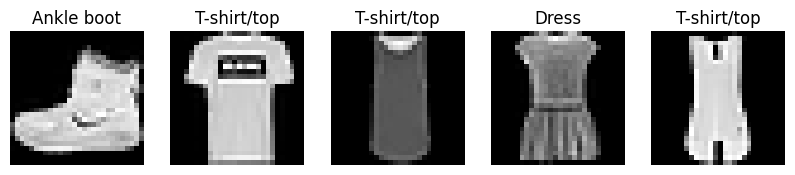

In [4]:
# Función para visualizar imágenes

def plot_images(images, labels, n=5):
    plt.figure(figsize=(10,4))
    
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")
    
    plt.show()

plot_images(train_images, train_labels, 5)


## Preprocesado
Normalizamos los píxeles al rango [0,1].

In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0


## 1. Construcción del modelo MLP

In [6]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()


c:\Users\elnom\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 2. Entrenamiento con validación y EarlyStopping

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_images,
    train_labels,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8166 - loss: 0.5183 - val_accuracy: 0.8468 - val_loss: 0.4288
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8608 - loss: 0.3816 - val_accuracy: 0.8695 - val_loss: 0.3580
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8737 - loss: 0.3420 - val_accuracy: 0.8738 - val_loss: 0.3450
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8825 - loss: 0.3182 - val_accuracy: 0.8806 - val_loss: 0.3513
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8885 - loss: 0.2989 - val_accuracy: 0.8679 - val_loss: 0.3577
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8947 - loss: 0.2833 - val_accuracy: 0.8820 - val_loss: 0.3258
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8987 - loss: 0.2699 - val_accuracy: 0.8841 - val_loss: 0.3294
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9020 - loss: 0.2603 - 

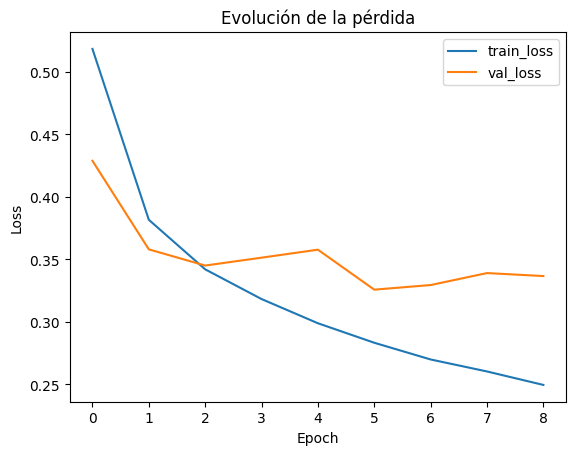

In [9]:
# Gráficas de entrenamiento

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Evolución de la pérdida")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


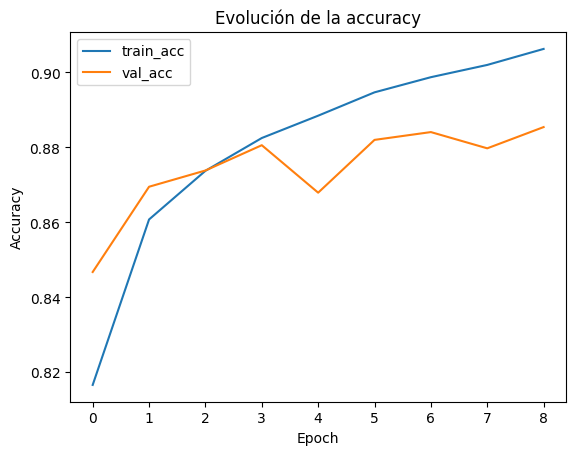

In [10]:
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Evolución de la accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


## 3. Evaluación en test

In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.8777 - loss: 0.3421
Test accuracy: 0.8776999711990356


In [12]:
# Predicciones
predictions = model.predict(test_images)
pred_labels = np.argmax(predictions, axis=1)

print(classification_report(test_labels, pred_labels, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.73      0.84      0.78      1000
       Dress       0.88      0.89      0.88      1000
        Coat       0.80      0.75      0.77      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.73      0.65      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



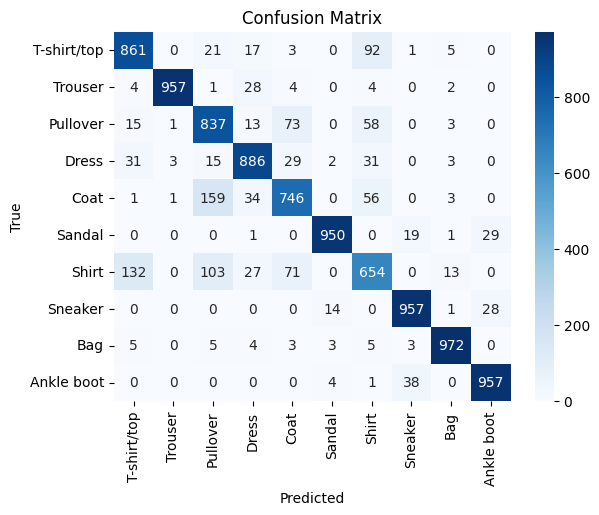

In [13]:
# Matriz de confusión

cm = confusion_matrix(test_labels, pred_labels)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


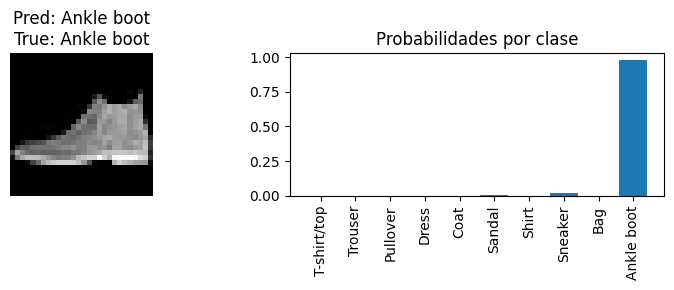

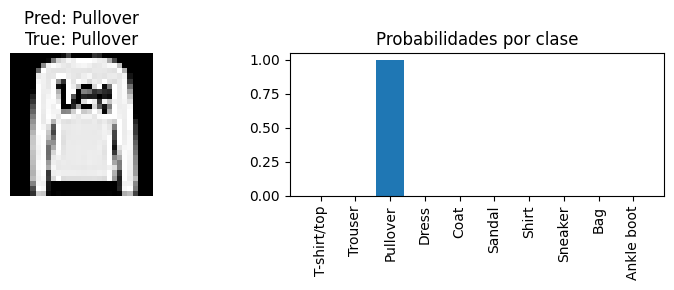

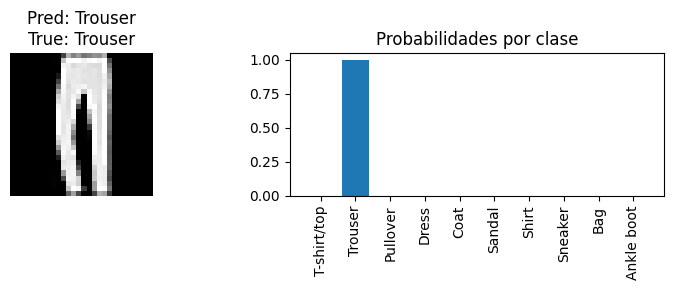

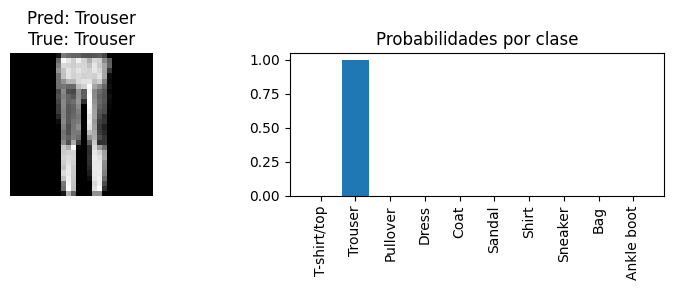

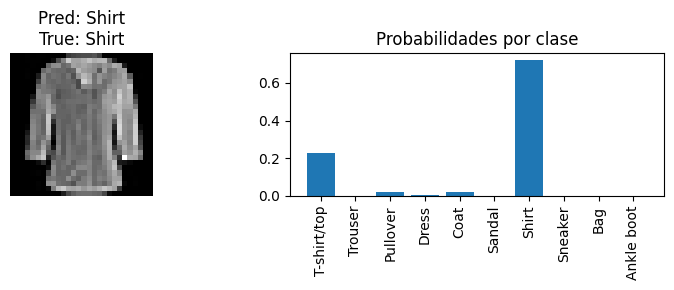

In [14]:
# Visualizar predicción con nivel de confianza

def plot_prediction(i):
    img = test_images[i]
    true_label = test_labels[i]
    pred_probs = predictions[i]
    pred_label = np.argmax(pred_probs)
    
    plt.figure(figsize=(8,3))
    
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.bar(range(10), pred_probs)
    plt.xticks(range(10), class_names, rotation=90)
    plt.title("Probabilidades por clase")
    
    plt.tight_layout()
    plt.show()

for i in range(5):
    plot_prediction(i)
